IMPORT AND LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import sys
sys.path.append('../src')
from preprocess import clean_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

df = pd.read_csv('../data/Reviews.csv')
df = df[df['Score'] != 3]
df.dropna(subset=['Text'], inplace=True)
df.drop_duplicates(subset=['Text'], inplace=True)
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)
df['clean_text'] = df['Text'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

#### LOAD VECTORISET AND TRANSFORM DATA

In [2]:
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
X_train_tfidf = vectorizer.transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

#### BUILD THE MODEL

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model_nn = Sequential([
    Dense(256, activation='relu', input_shape=(10000,)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_nn.summary()

c:\Users\Admin\Documents\GitHub\Valentine\amazon-sentiment-analysis\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,305 (9.90 MB)

 Trainable params: 2,593,793 (9.89 MB)

 Non-trainable params: 512 (2.00 KB)

#### TRAIN THE MODEL

In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_tfidf, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
3639/3639 ━━━━━━━━━━━━━━━━━━━━ 121s 32ms/step - accuracy: 0.9293 - loss: 0.1782 - val_accuracy: 0.9385 - val_loss: 0.1559
Epoch 2/20
3639/3639 ━━━━━━━━━━━━━━━━━━━━ 109s 30ms/step - accuracy: 0.9470 - loss: 0.1310 - val_accuracy: 0.9400 - val_loss: 0.1513
Epoch 3/20
3639/3639 ━━━━━━━━━━━━━━━━━━━━ 110s 30ms/step - accuracy: 0.9644 - loss: 0.0909 - val_accuracy: 0.9398 - val_loss: 0.1664
Epoch 4/20
3639/3639 ━━━━━━━━━━━━━━━━━━━━ 109s 30ms/step - accuracy: 0.9788 - loss: 0.0571 - val_accuracy: 0.9381 - val_loss: 0.1849
Epoch 5/20
3639/3639 ━━━━━━━━━━━━━━━━━━━━ 108s 30ms/step - accuracy: 0.9855 - loss: 0.0411 - val_accuracy: 0.9386 - val_loss: 0.2217


PLOT TRAINING CURVES

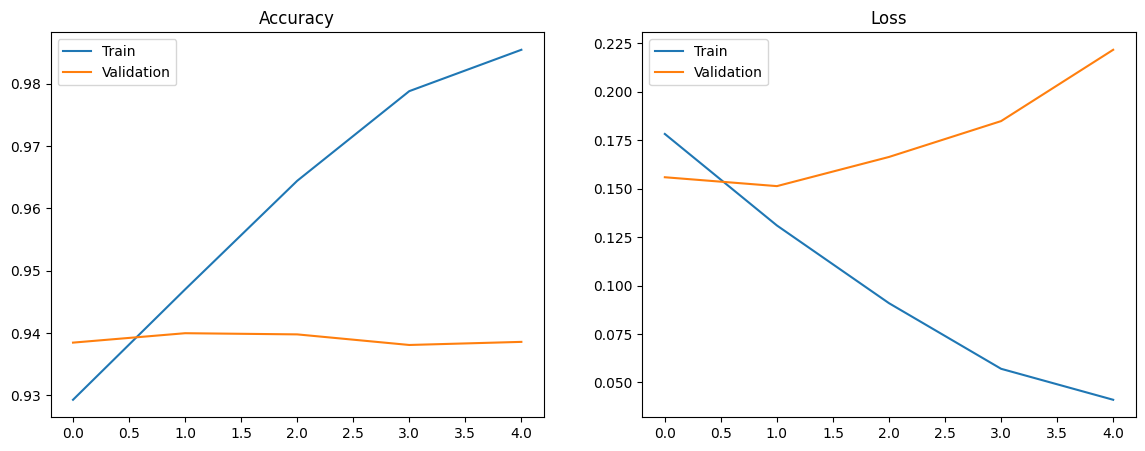

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.savefig('../data/training_curves.png')
plt.show()

EVALUATE THE MODEL AND SAVE

2274/2274 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
              precision    recall  f1-score   support

           0       0.84      0.78      0.81     11414
           1       0.96      0.97      0.97     61354

    accuracy                           0.94     72768
   macro avg       0.90      0.88      0.89     72768
weighted avg       0.94      0.94      0.94     72768



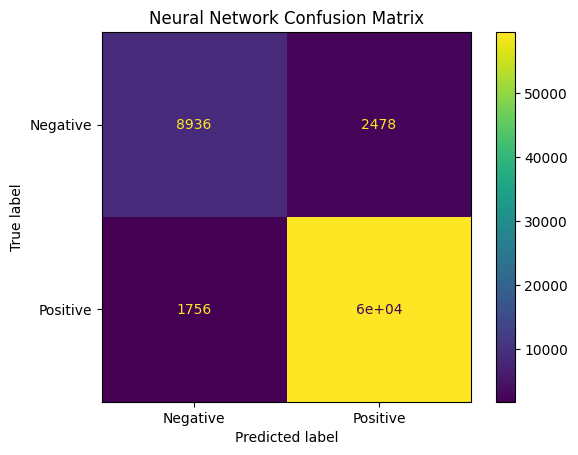

Neural network saved.


In [ ]:
y_pred_nn = (model_nn.predict(X_test_tfidf) > 0.5).astype(int)
print(classification_report(y_test, y_pred_nn))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn,
    display_labels=['Negative', 'Positive']
)
plt.title('Neural Network Confusion Matrix')
plt.savefig('../data/confusion_matrix_nn.png')
plt.show()

os.makedirs('../models', exist_ok=True)
model_nn.save('../models/nn_model.keras')
print("Neural network saved.")